# dGen Results Visualization Notebook

## 0. Set Up Code

In [6]:
import os
import pandas as pd
import geopandas as gpd
import fiona
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
import requests
import numpy as np

## 1. Import dGen Results

In [7]:
# Define the name of the folder, within the current file path of this jupyter notebook, where the dgen results are stored as csv files
results_folder = 'dgen_results'

# Create a dictionary to hold all the DataFrames, which correspond to the dgen results csv files
scenario_dictionary = {}

# Loop through all dgen results csv files in the folder and extract the data
for file in os.listdir(results_folder):
    if file.endswith('.csv'):
        df_name = os.path.splitext(file)[0]  # remove .csv extension
        file_path = os.path.join(results_folder, file)
        scenario_dictionary[df_name] = pd.read_csv(file_path)

# List all DataFrames created (results files)
print('dgen scenario results:', list(scenario_dictionary.keys()))

dgen scenario results: ['guam_com_advanced_results_10_15', 'guam_com_baseline_results_10_15', 'guam_com_high_load_results_10_15', 'guam_res_advanced_results_10_15', 'guam_res_baseline_results_10_15', 'guam_res_high_load_results_10_15']


## 2. View dGen Results

In [8]:
# Print the column names (same across all data files)
print('Column names:', list(next(iter(scenario_dictionary.values())).columns))
print('\n')

# Loop through all DataFrames in scenario_dictionary and display results
for df_name, df in scenario_dictionary.items():
    print(f'--- {df_name} ---')  # label with the DataFrame name
    display(df.head())           # display the first few rows
    print('\n')

Column names: ['pgid', 'bin_id', 'bldg_id', 'ba', 'county_id', 'statefp', 'state_abbr', 'census_division_abbr', 'municipality', 'cdp_name', 'military', 'cdp_fips', 'sector_abbr', 'tech', 'total_res_population', 'frac_res_pop', 'total_res_households', 'total_com_customers', 'sales_elec_kwh_to_customers', 'monthly_kwh', 'developable_roof_sqft', 'cap_cost_multiplier', 'solar_re_9809_gid', 'tilt', 'azimuth', 'pct_of_bldgs_developable', 'bldg_size_class', 'i', 'j', 'eia_id', 'tariff_name', 'total_population', 'year', 'total_sales_kwh', 'load_multiplier', 'load_kwh_per_customer_in_bin', 'customers_in_bin', 'compensation_style', 'nem_system_kw_limit', 'elec_price_multiplier', 'elec_price_escalator', 'batt_eff', 'batt_lifetime_yrs', 'pv_kw_per_sqft', 'pv_degradation_factor', 'system_capex_per_kw_res_atb', 'res_frac_change', 'system_capex_per_kw_com_atb', 'com_frac_change', 'system_capex_per_kw', 'system_om_per_kw', 'system_variable_om_per_kw', 'batt_capex_per_kwh', 'batt_capex_per_kw', 'linear

,pgid,bin_id,bldg_id,ba,county_id,statefp,state_abbr,census_division_abbr,municipality,cdp_name,...,new_market_share,new_adopters,new_system_kw,new_batt_kw,new_batt_kwh,number_of_adopters,system_kw_cum,batt_kw_cum,batt_kwh_cum,max_market_share_last_year
0,1,1,13953,p102,1148,66,FL,SA,Mangilao,Adacao,...,0.027663,0.610129,4.159238,0.0,0.0,0.359893,35.989300,0.899992,0.046075,NaN
1,1,1,13953,p102,1148,66,FL,SA,Mangilao,Adacao,...,0.026874,1.605252,10.942971,0.0,0.0,0.970811,97.081063,2.437394,0.124781,NaN
2,1,1,13953,p102,1148,66,FL,SA,Mangilao,Adacao,...,0.028033,0.128235,0.874178,0.0,0.0,0.074781,7.478059,0.186658,0.009556,NaN
3,1,1,13953,p102,1148,66,FL,SA,Mangilao,Adacao,...,0.028704,0.860569,5.866482,0.0,0.0,0.491772,49.177184,1.223382,0.062630,NaN
4,1,1,13953,p102,1148,66,FL,SA,Mangilao,Adacao,...,0.028704,0.199132,1.357481,0.0,0.0,0.113794,11.379408,0.283086,0.014492,NaN




--- guam_com_baseline_results_10_15 ---


Column names: ['pgid', 'bin_id', 'bldg_id', 'ba', 'county_id', 'statefp', 'state_abbr', 'census_division_abbr', 'municipality', 'cdp_name', 'military', 'cdp_fips', 'sector_abbr', 'tech', 'total_res_population', 'frac_res_pop', 'total_res_households', 'total_com_customers', 'sales_elec_kwh_to_customers', 'monthly_kwh', 'developable_roof_sqft', 'cap_cost_multiplier', 'solar_re_9809_gid', 'tilt', 'azimuth', 'pct_of_bldgs_developable', 'bldg_size_class', 'i', 'j', 'eia_id', 'tariff_name', 'total_population', 'year', 'total_sales_kwh', 'load_multiplier', 'load_kwh_per_customer_in_bin', 'customers_in_bin', 'compensation_style', 'nem_system_kw_limit', 'elec_price_multiplier', 'elec_price_escalator', 'batt_eff', 'batt_lifetime_yrs', 'pv_kw_per_sqft', 'pv_degradation_factor', 'system_capex_per_kw_res_atb', 'res_frac_change', 'system_capex_per_kw_com_atb', 'com_frac_change', 'system_capex_per_kw', 'system_om_per_kw', 'system_variable_om_per_kw', 'batt_capex_per_kwh', 'batt_capex_per_kw', 'linear

,pgid,bin_id,bldg_id,ba,county_id,statefp,state_abbr,census_division_abbr,municipality,cdp_name,...,new_market_share,new_adopters,new_system_kw,new_batt_kw,new_batt_kwh,number_of_adopters,system_kw_cum,batt_kw_cum,batt_kwh_cum,max_market_share_last_year
0,1,1,13953,p102,1148,66,FL,SA,Mangilao,Adacao,...,0.027663,0.610129,4.159238,0.0,0.0,0.359893,35.989300,0.899992,0.046075,NaN
1,1,1,13953,p102,1148,66,FL,SA,Mangilao,Adacao,...,0.026874,1.605252,10.942971,0.0,0.0,0.970811,97.081063,2.437394,0.124781,NaN
2,1,1,13953,p102,1148,66,FL,SA,Mangilao,Adacao,...,0.028033,0.128235,0.874178,0.0,0.0,0.074781,7.478059,0.186658,0.009556,NaN
3,1,1,13953,p102,1148,66,FL,SA,Mangilao,Adacao,...,0.028704,0.860569,5.866482,0.0,0.0,0.491772,49.177184,1.223382,0.062630,NaN
4,1,1,13953,p102,1148,66,FL,SA,Mangilao,Adacao,...,0.028704,0.199132,1.357481,0.0,0.0,0.113794,11.379408,0.283086,0.014492,NaN


...

,pgid,bin_id,bldg_id,ba,county_id,statefp,state_abbr,census_division_abbr,municipality,cdp_name,...,new_market_share,new_adopters,new_system_kw,new_batt_kw,new_batt_kwh,number_of_adopters,system_kw_cum,batt_kw_cum,batt_kwh_cum,max_market_share_last_year
0,15,5,23565,p102,1148,66,FL,SA,Mangilao,Adacao,...,0.041957,3.020894,1.152679,0.0,0.0,6.398882,31.994408,0.490206,0.571221,NaN
1,15,5,23565,p102,1148,66,FL,SA,Mangilao,Adacao,...,0.043157,49.026368,364.672919,0.0,0.0,157.453116,787.265582,7.734359,9.012603,NaN
2,40,10,23565,p102,1148,66,FL,SA,Sinajana,Afame,...,0.041957,3.860031,1.472867,0.0,0.0,8.176349,40.881743,0.626374,0.729894,NaN
3,40,10,23565,p102,1148,66,FL,SA,Sinajana,Afame,...,0.043157,7.854577,58.424711,0.0,0.0,25.225763,126.128817,1.239131,1.443921,NaN
4,65,15,23565,p102,1148,66,FL,SA,Agana Heights,Agana Heights,...,0.041957,14.349245,5.475224,0.0,0.0,30.394687,151.973437,2.328478,2.713301,NaN




--- guam_res_baseline_results_10_15 ---


,pgid,bin_id,bldg_id,ba,county_id,statefp,state_abbr,census_division_abbr,municipality,cdp_name,...,new_market_share,new_adopters,new_system_kw,new_batt_kw,new_batt_kwh,number_of_adopters,system_kw_cum,batt_kw_cum,batt_kwh_cum,max_market_share_last_year
0,15,5,23565,p102,1148,66,FL,SA,Mangilao,Adacao,...,0.041957,3.020894,1.152679,0.0,0.0,6.398882,31.994408,0.490206,0.571221,NaN
1,15,5,23565,p102,1148,66,FL,SA,Mangilao,Adacao,...,0.043157,49.026368,364.672919,0.0,0.0,157.453116,787.265582,7.734359,9.012603,NaN
2,40,10,23565,p102,1148,66,FL,SA,Sinajana,Afame,...,0.041957,3.860031,1.472867,0.0,0.0,8.176349,40.881743,0.626374,0.729894,NaN
3,40,10,23565,p102,1148,66,FL,SA,Sinajana,Afame,...,0.043157,7.854577,58.424711,0.0,0.0,25.225763,126.128817,1.239131,1.443921,NaN
4,65,15,23565,p102,1148,66,FL,SA,Agana Heights,Agana Heights,...,0.041957,14.349245,5.475224,0.0,0.0,30.394687,151.973437,2.328478,2.713301,NaN




--- guam_res_high_load_results_10_15 ---


,pgid,bin_id,bldg_id,ba,county_id,statefp,state_abbr,census_division_abbr,municipality,cdp_name,...,new_market_share,new_adopters,new_system_kw,new_batt_kw,new_batt_kwh,number_of_adopters,system_kw_cum,batt_kw_cum,batt_kwh_cum,max_market_share_last_year
0,15,5,23565,p102,1148,66,FL,SA,Mangilao,Adacao,...,0.041957,3.020894,1.152679,0.0,0.0,6.398882,31.994408,0.490206,0.571221,NaN
1,15,5,23565,p102,1148,66,FL,SA,Mangilao,Adacao,...,0.043157,49.026368,364.672919,0.0,0.0,157.453116,787.265582,7.734359,9.012603,NaN
2,40,10,23565,p102,1148,66,FL,SA,Sinajana,Afame,...,0.041957,3.860031,1.472867,0.0,0.0,8.176349,40.881743,0.626374,0.729894,NaN
3,40,10,23565,p102,1148,66,FL,SA,Sinajana,Afame,...,0.043157,7.854577,58.424711,0.0,0.0,25.225763,126.128817,1.239131,1.443921,NaN
4,65,15,23565,p102,1148,66,FL,SA,Agana Heights,Agana Heights,...,0.041957,14.349245,5.475224,0.0,0.0,30.394687,151.973437,2.328478,2.713301,NaN


## 3. Plot Results: Distributed PV Deployment by Scenario

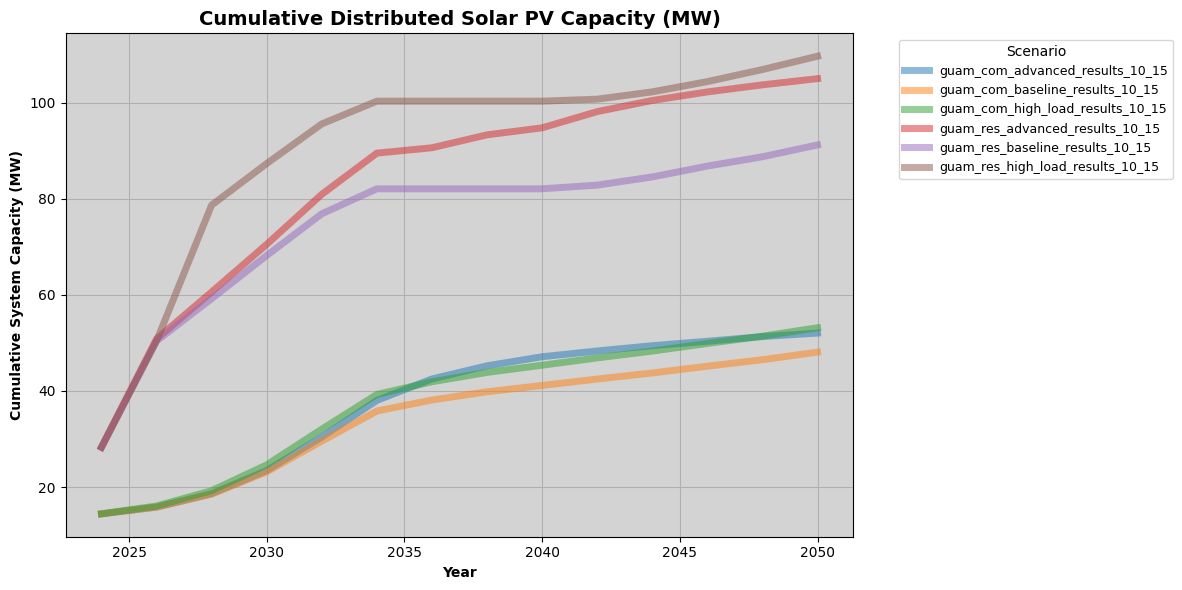

In [9]:
# =========================
# Chart 1: Capacity (MW)
# =========================

# Define a consistent color palette
colors_capacity = plt.cm.tab10.colors  

# Create a plot
fig_capacity, ax_capacity = plt.subplots(figsize=(12, 6))

# Loop through each DataFrame in the dictionary
for i, (name, df) in enumerate(scenario_dictionary.items()):
    # Aggregate system_kw_cum by year and convert kW → MW
    df_grouped_capacity = df.groupby('year', as_index=False)['system_kw_cum'].sum()
    df_grouped_capacity['system_mw_cum'] = df_grouped_capacity['system_kw_cum'] / 1000
    
    # Plot line for this scenario
    ax_capacity.plot(df_grouped_capacity['year'], df_grouped_capacity['system_mw_cum'], 
                     label=name, color=colors_capacity[i % len(colors_capacity)], linewidth=5, alpha=0.5)

# Formatting
ax_capacity.set_facecolor('lightgray')
ax_capacity.grid(True)

ax_capacity.set_title('Cumulative Distributed Solar PV Capacity (MW)', fontsize=14, fontweight='bold')
ax_capacity.set_xlabel('Year', fontsize=10, fontweight='bold')
ax_capacity.set_ylabel('Cumulative System Capacity (MW)', fontsize=10, fontweight='bold')

# Move legend outside the plot
ax_capacity.legend(title='Scenario', fontsize=9, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 4. Plot Results: Distributed PV Generation by Scenario

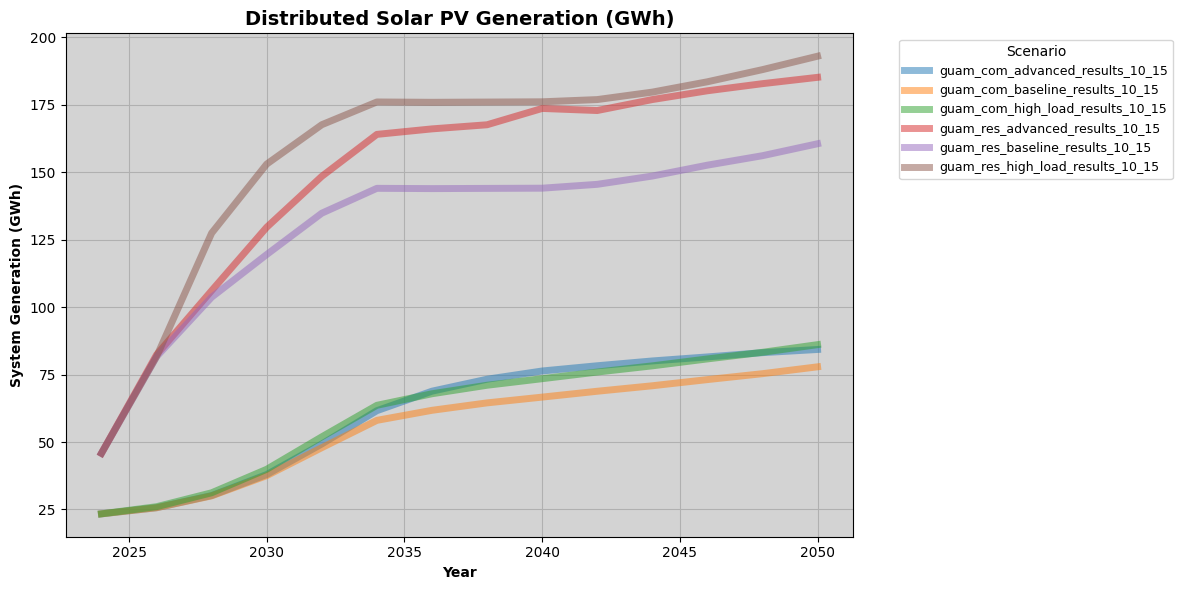

In [10]:
# =========================
# Chart 2: Generation (GWh)
# =========================

# Define a consistent color palette
colors_generation = plt.cm.tab10.colors  

# Create a plot
fig_generation, ax_generation = plt.subplots(figsize=(12, 6))

# Loop through each DataFrame in the dictionary
for i, (name, df) in enumerate(scenario_dictionary.items()):
    # Aggregate system capacity and capacity factor by year
    df_grouped_generation = (
        df.groupby('year', as_index=False)
          .agg({
              'system_kw_cum': 'sum',
              'capacity_factor': 'mean'
          })
    )
    
    # Estimate generation (kWh) = capacity (kW) × capacity factor × 8760 hours
    df_grouped_generation['annual_energy_production_kwh'] = (
        df_grouped_generation['system_kw_cum'] * 
        df_grouped_generation['capacity_factor'] * 
        8760
    )
    
    # Convert kWh → MWh
    df_grouped_generation['annual_energy_production_gwh'] = (
        df_grouped_generation['annual_energy_production_kwh'] / 1000000
    )
    
    # Plot line for this scenario
    ax_generation.plot(df_grouped_generation['year'], df_grouped_generation['annual_energy_production_gwh'], 
                       label=name, color=colors_generation[i % len(colors_generation)], linewidth=5, alpha=0.5)

# Formatting
ax_generation.set_facecolor('lightgray')
ax_generation.grid(True)

ax_generation.set_title('Distributed Solar PV Generation (GWh)', fontsize=14, fontweight='bold')
ax_generation.set_xlabel('Year', fontsize=10, fontweight='bold')
ax_generation.set_ylabel('System Generation (GWh)', fontsize=10, fontweight='bold')

# Move legend outside the plot
ax_generation.legend(title='Scenario', fontsize=9, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 5. Plot Results: Payback Period by Scenario

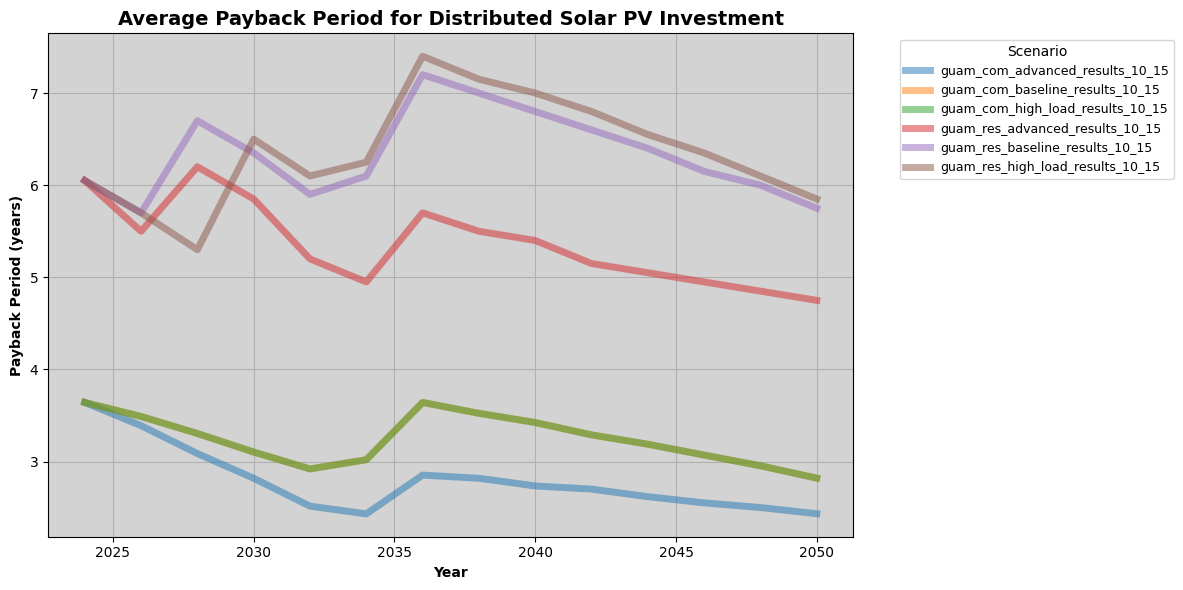

In [12]:
# =========================
# Chart 3: Payback Period (years)
# =========================

# Define a consistent color palette
colors_payback = plt.cm.tab10.colors  

# Create a plot
fig_payback, ax_payback = plt.subplots(figsize=(12, 6))

# Loop through each DataFrame in the dictionary
for i, (name, df) in enumerate(scenario_dictionary.items()):
    # Average payback period by year
    df_grouped_payback = df.groupby('year', as_index=False)['payback_period'].mean()
    
    # Plot line for this scenario
    ax_payback.plot(df_grouped_payback['year'], df_grouped_payback['payback_period'], 
                       label=name, color=colors_payback[i % len(colors_payback)], linewidth=5, alpha=0.5)

# Formatting
ax_payback.set_facecolor('lightgray')
ax_payback.grid(True)

ax_payback.set_title('Average Payback Period for Distributed Solar PV Investment', fontsize=14, fontweight='bold')
ax_payback.set_xlabel('Year', fontsize=10, fontweight='bold')
ax_payback.set_ylabel('Payback Period (years)', fontsize=10, fontweight='bold')

# Move legend outside the plot
ax_payback.legend(title='Scenario', fontsize=9, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 6. Plot Results: Cumulative Distributed Solar PV Capacity (MW) by Municipality and Year

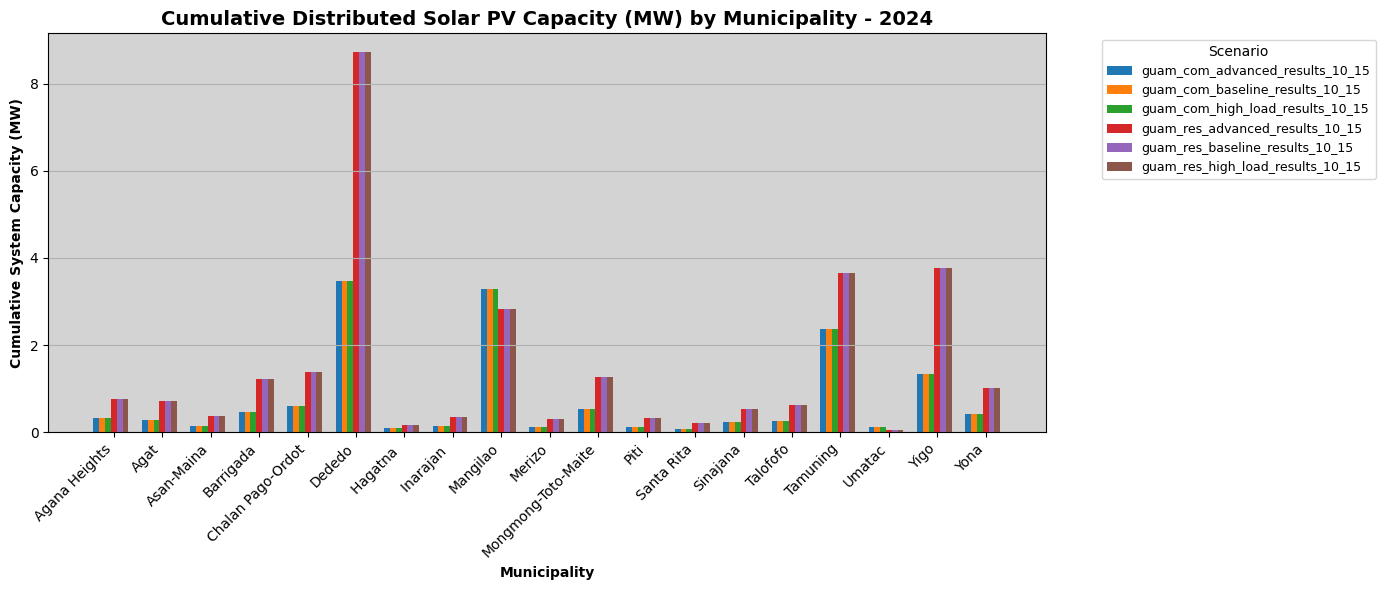

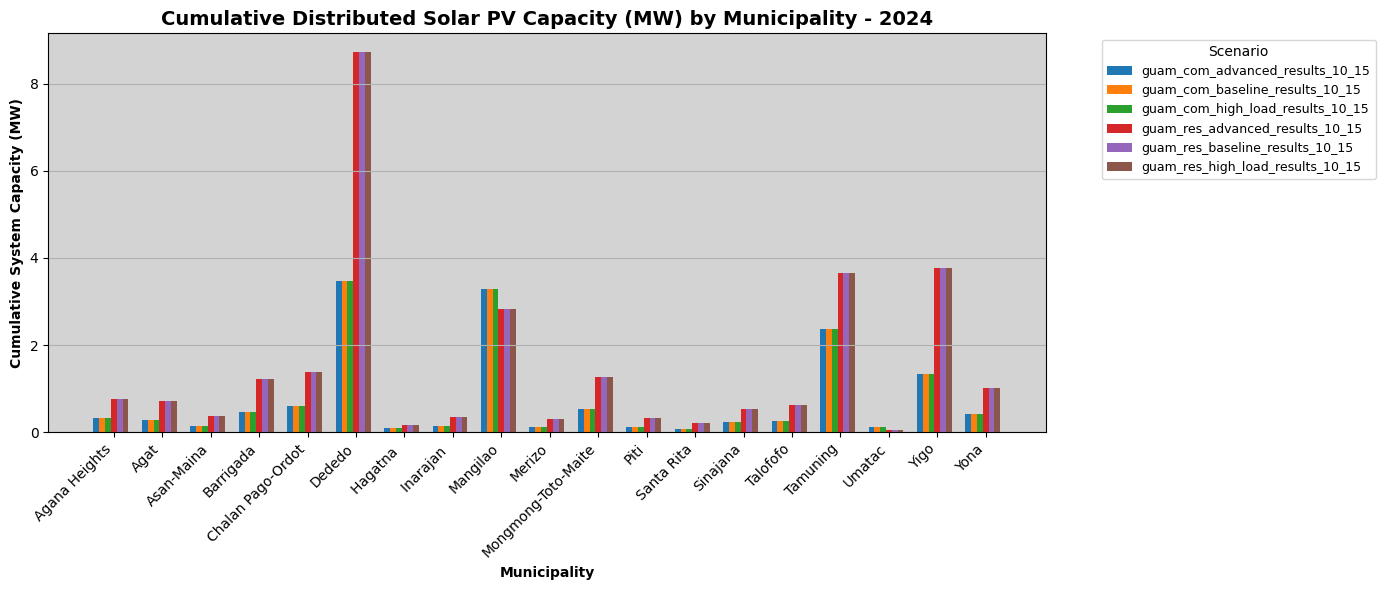

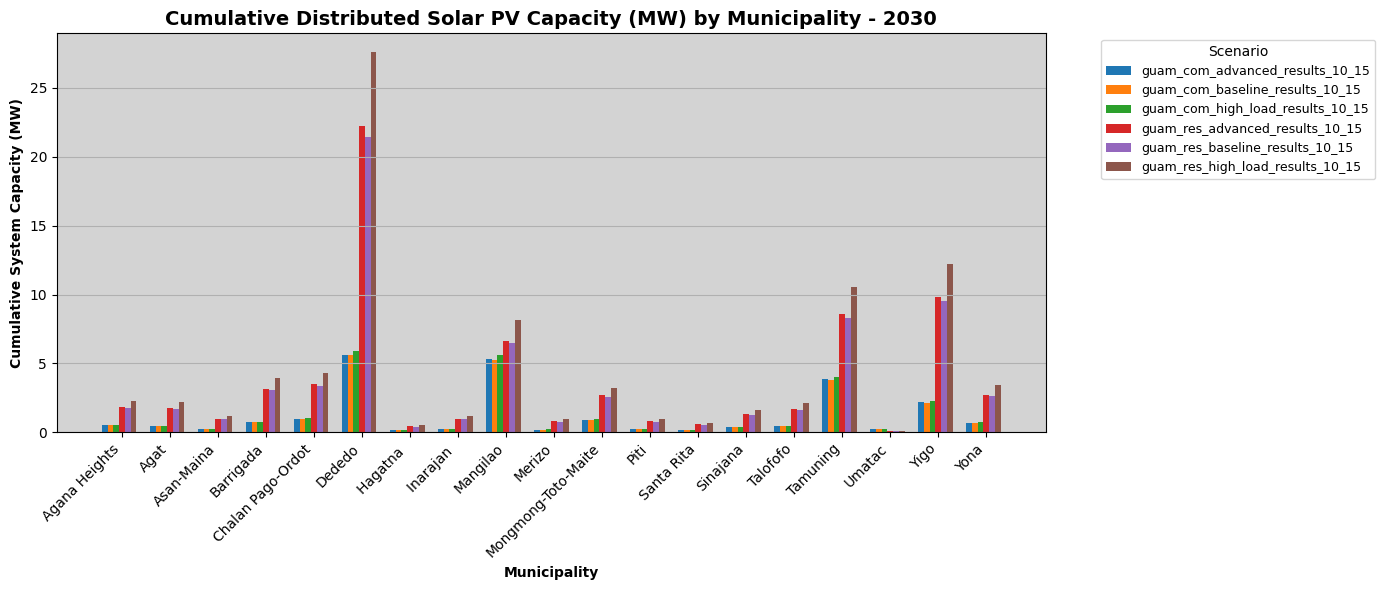

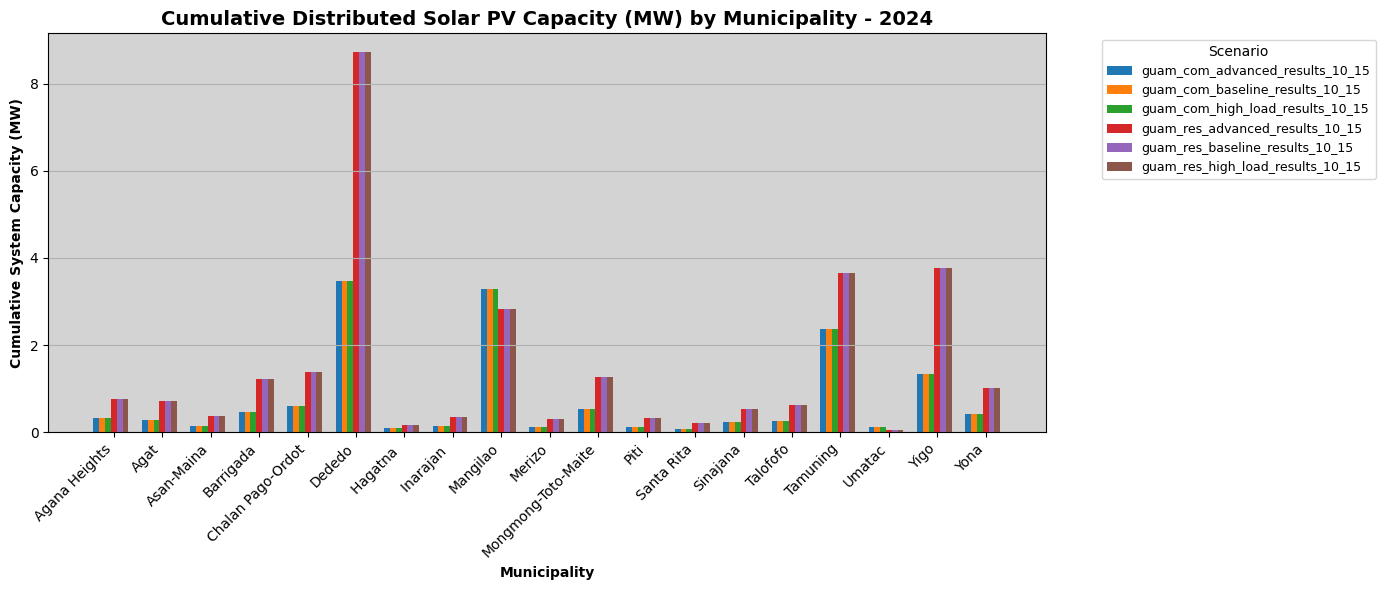

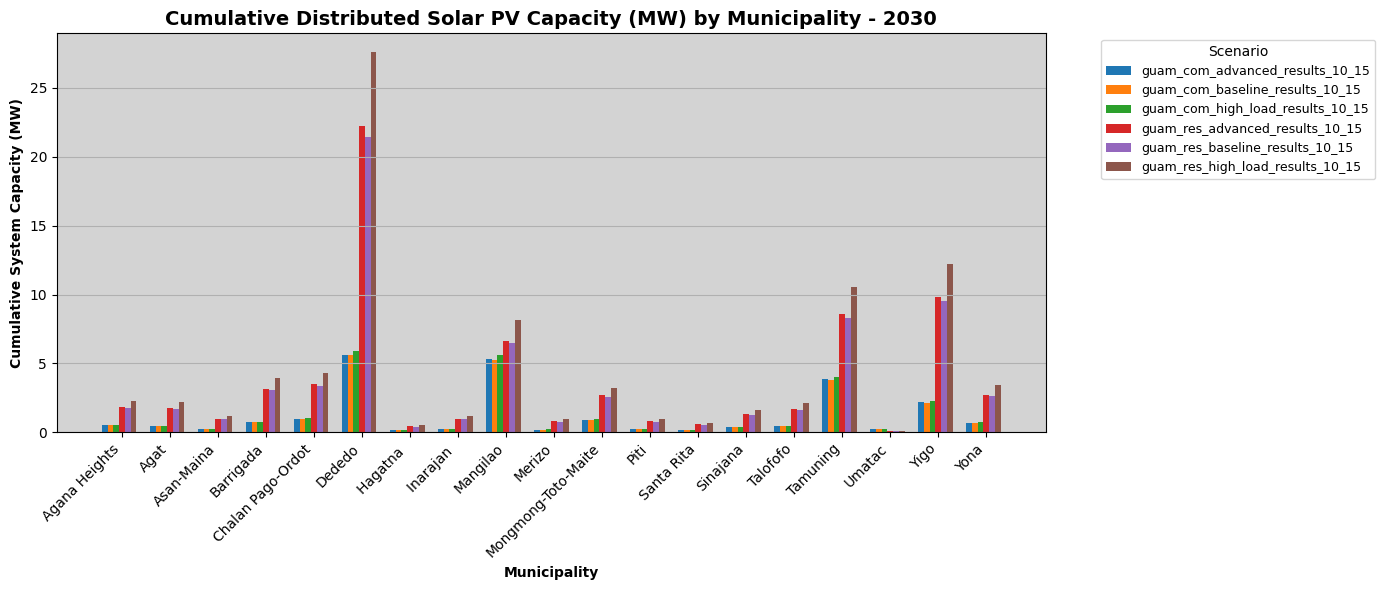

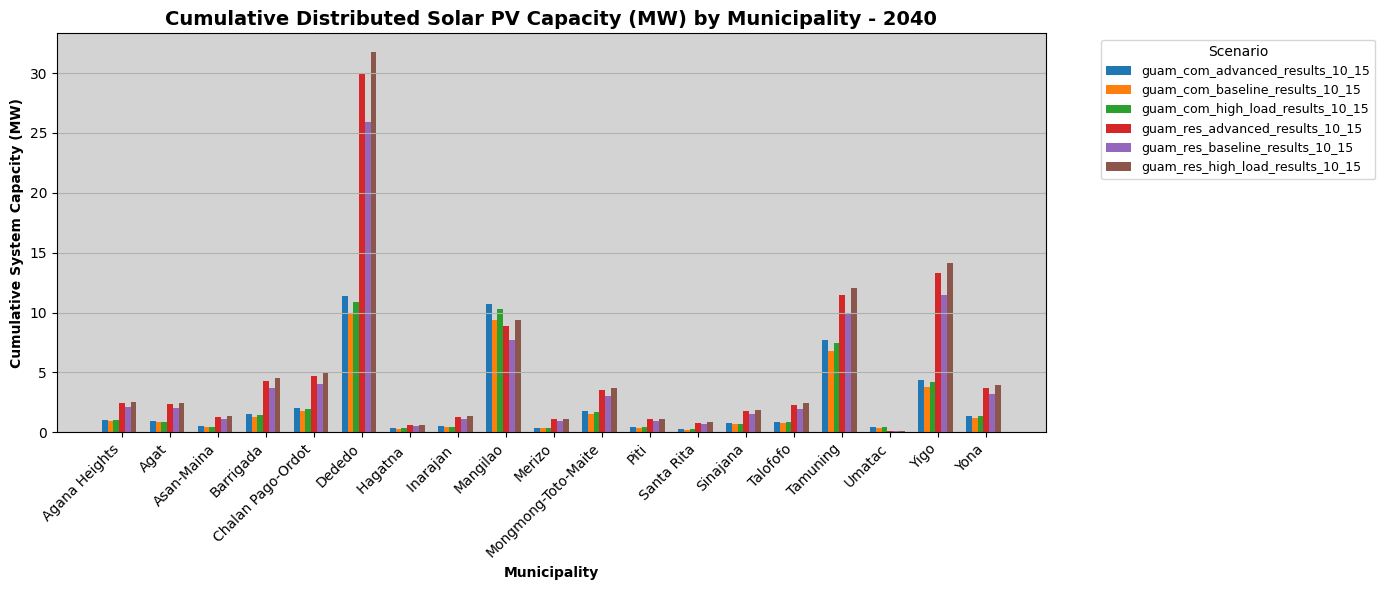

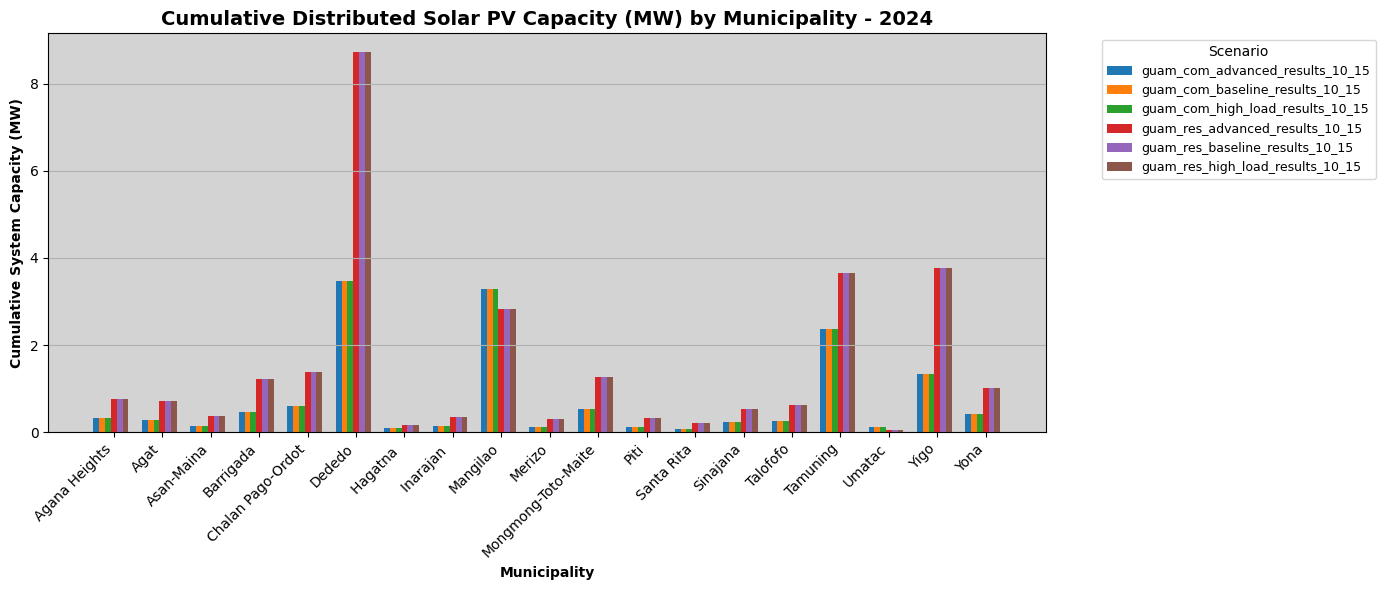

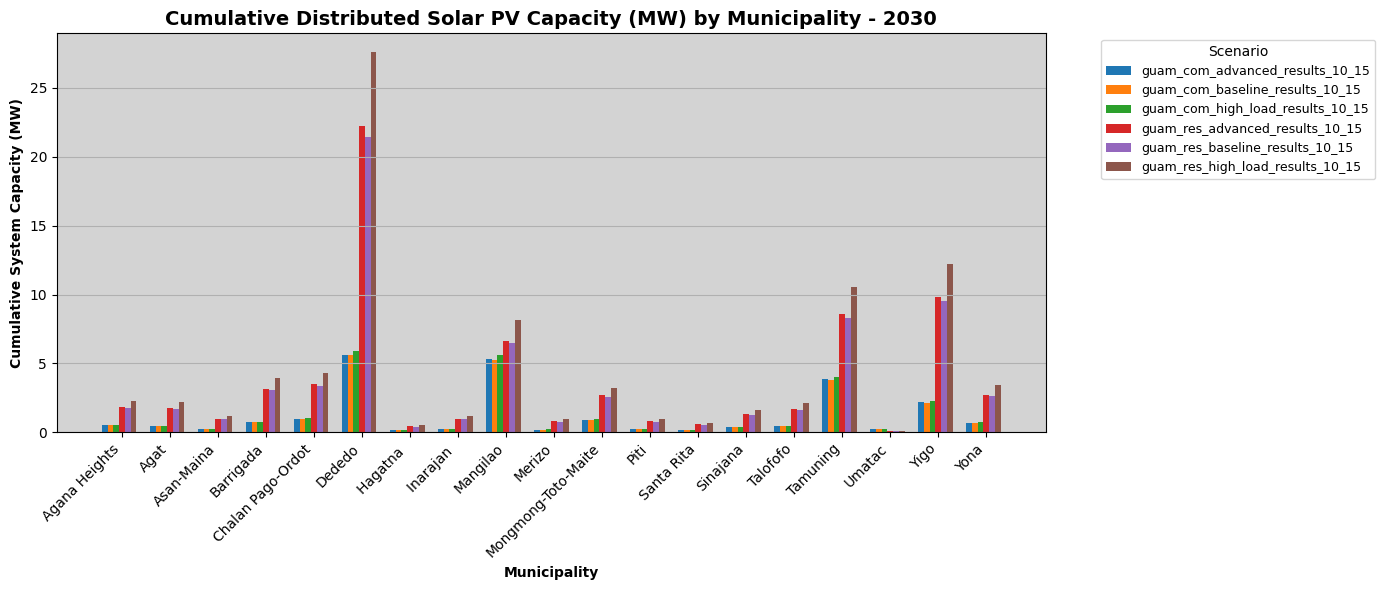

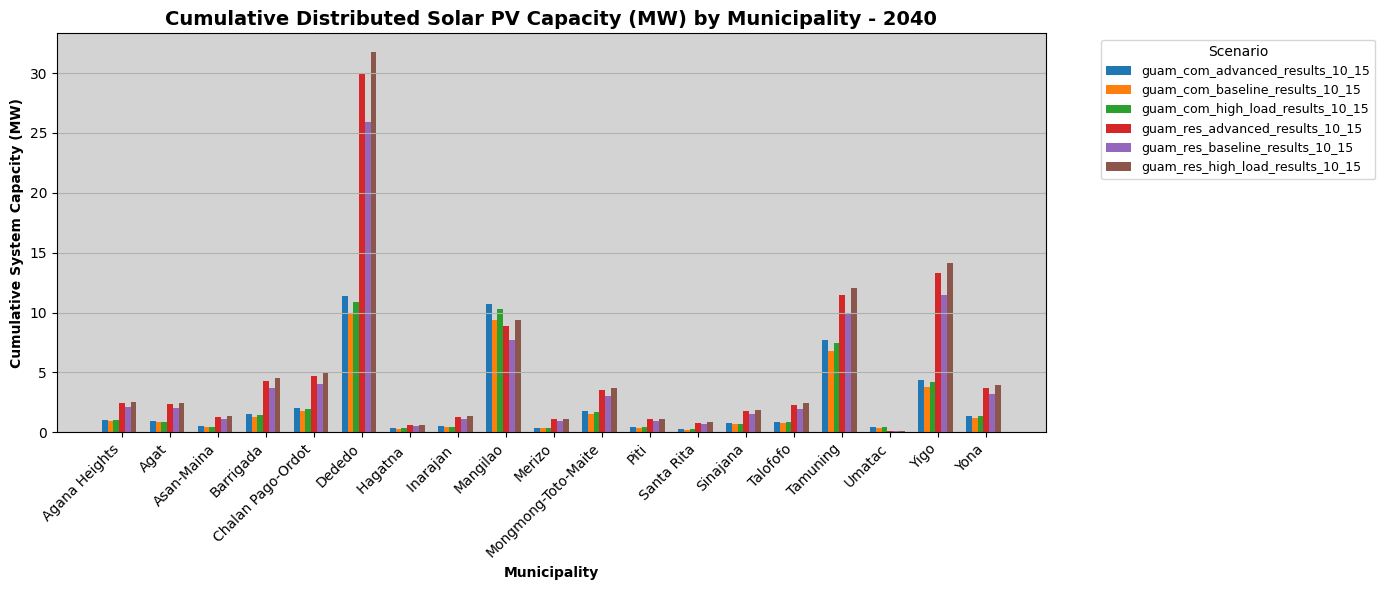

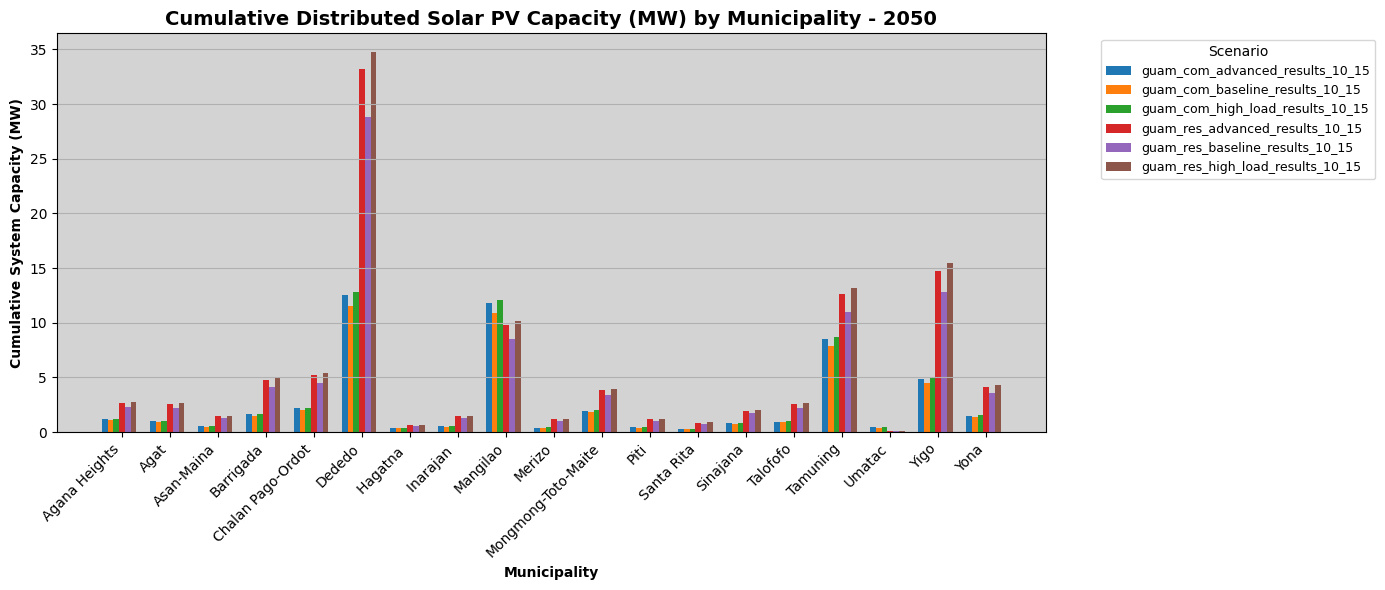

In [13]:
# =========================
# Chart 4: Capacity (MW) by Municipality
# =========================

# Years to plot
years_to_plot = [2024, 2030, 2040, 2050]

# Define a consistent color palette
colors_bar = plt.cm.tab10.colors  

# Loop through each year to make a clustered bar chart
for year in years_to_plot:
    fig, ax = plt.subplots(figsize=(14, 6))

    # Collect all municipalities from all scenarios
    all_munis = set()
    for df in scenario_dictionary.values():
        all_munis.update(df[df['year'] == year]['municipality'].unique())
    all_munis = sorted(list(all_munis))

    # X positions for municipalities
    x = np.arange(len(all_munis))
    bar_width = 0.12  # adjust based on number of scenarios

    # Plot bars for each scenario
    for i, (name, df) in enumerate(scenario_dictionary.items()):
        df_year = df[df['year'] == year].groupby('municipality', as_index=False)['system_kw_cum'].sum()
        df_year['system_mw_cum'] = df_year['system_kw_cum'] / 1000
        df_year_dict = df_year.set_index('municipality')['system_mw_cum'].to_dict()

        # Ensure all municipalities exist (fill with 0 if missing)
        values = [df_year_dict.get(m, 0) for m in all_munis]

        # Plot bars, shift each scenario
        ax.bar(
            x + i * bar_width, 
            values, 
            width=bar_width, 
            label=name,
            color=colors_bar[i % len(colors_bar)]
        )

    # Formatting
    ax.set_title(f'Cumulative Distributed Solar PV Capacity (MW) by Municipality - {year}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Municipality', fontsize=10, fontweight='bold')
    ax.set_ylabel('Cumulative System Capacity (MW)', fontsize=10, fontweight='bold')
    ax.set_xticks(x + bar_width * (len(scenario_dictionary) / 2))
    ax.set_xticklabels(all_munis, rotation=45, ha='right')

    ax.legend(title='Scenario', fontsize=9, bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.set_facecolor('lightgray')
    ax.grid(True, axis = 'y')

    plt.tight_layout()
    plt.show()

## 7. Plot Results: Electricity Consumption (GWh) by Scenario

--- guam_com_advanced_results_10_15 ---


--- guam_com_advanced_results_10_15 ---


,pgid,bin_id,bldg_id,ba,county_id,statefp,state_abbr,census_division_abbr,municipality,cdp_name,...,new_adopters,new_system_kw,new_batt_kw,new_batt_kwh,number_of_adopters,system_kw_cum,batt_kw_cum,batt_kwh_cum,max_market_share_last_year,load_kwh
0,1,1,13953,p102,1148,66,FL,SA,Mangilao,Adacao,...,0.610129,4.159238,0.0,0.0,0.359893,35.989300,0.899992,0.046075,NaN,1.784973e+06
1,1,1,13953,p102,1148,66,FL,SA,Mangilao,Adacao,...,1.605252,10.942971,0.0,0.0,0.970811,97.081063,2.437394,0.124781,NaN,4.834136e+06
2,1,1,13953,p102,1148,66,FL,SA,Mangilao,Adacao,...,0.128235,0.874178,0.0,0.0,0.074781,7.478059,0.186658,0.009556,NaN,3.702021e+05
3,1,1,13953,p102,1148,66,FL,SA,Mangilao,Adacao,...,0.860569,5.866482,0.0,0.0,0.491772,49.177184,1.223382,0.062630,NaN,2.426360e+06
4,1,1,13953,p102,1148,66,FL,SA,Mangilao,Adacao,...,0.199132,1.357481,0.0,0.0,0.113794,11.379408,0.283086,0.014492,NaN,5.614503e+05




--- guam_com_baseline_results_10_15 ---


--- guam_com_advanced_results_10_15 ---


...

,pgid,bin_id,bldg_id,ba,county_id,statefp,state_abbr,census_division_abbr,municipality,cdp_name,...,new_adopters,new_system_kw,new_batt_kw,new_batt_kwh,number_of_adopters,system_kw_cum,batt_kw_cum,batt_kwh_cum,max_market_share_last_year,load_kwh
0,15,5,23565,p102,1148,66,FL,SA,Mangilao,Adacao,...,3.020894,1.152679,0.0,0.0,6.398882,31.994408,0.490206,0.571221,NaN,5.849039e+04
1,15,5,23565,p102,1148,66,FL,SA,Mangilao,Adacao,...,49.026368,364.672919,0.0,0.0,157.453116,787.265582,7.734359,9.012603,NaN,1.915015e+07
2,40,10,23565,p102,1148,66,FL,SA,Sinajana,Afame,...,3.860031,1.472867,0.0,0.0,8.176349,40.881743,0.626374,0.729894,NaN,7.473772e+04
3,40,10,23565,p102,1148,66,FL,SA,Sinajana,Afame,...,7.854577,58.424711,0.0,0.0,25.225763,126.128817,1.239131,1.443921,NaN,3.068069e+06
4,65,15,23565,p102,1148,66,FL,SA,Agana Heights,Agana Heights,...,14.349245,5.475224,0.0,0.0,30.394687,151.973437,2.328478,2.713301,NaN,2.778293e+05




--- guam_res_baseline_results_10_15 ---


,pgid,bin_id,bldg_id,ba,county_id,statefp,state_abbr,census_division_abbr,municipality,cdp_name,...,new_adopters,new_system_kw,new_batt_kw,new_batt_kwh,number_of_adopters,system_kw_cum,batt_kw_cum,batt_kwh_cum,max_market_share_last_year,load_kwh
0,15,5,23565,p102,1148,66,FL,SA,Mangilao,Adacao,...,3.020894,1.152679,0.0,0.0,6.398882,31.994408,0.490206,0.571221,NaN,5.849039e+04
1,15,5,23565,p102,1148,66,FL,SA,Mangilao,Adacao,...,49.026368,364.672919,0.0,0.0,157.453116,787.265582,7.734359,9.012603,NaN,1.915015e+07
2,40,10,23565,p102,1148,66,FL,SA,Sinajana,Afame,...,3.860031,1.472867,0.0,0.0,8.176349,40.881743,0.626374,0.729894,NaN,7.473772e+04
3,40,10,23565,p102,1148,66,FL,SA,Sinajana,Afame,...,7.854577,58.424711,0.0,0.0,25.225763,126.128817,1.239131,1.443921,NaN,3.068069e+06
4,65,15,23565,p102,1148,66,FL,SA,Agana Heights,Agana Heights,...,14.349245,5.475224,0.0,0.0,30.394687,151.973437,2.328478,2.713301,NaN,2.778293e+05




--- guam_res_high_load_results_10_15 ---


,pgid,bin_id,bldg_id,ba,county_id,statefp,state_abbr,census_division_abbr,municipality,cdp_name,...,new_adopters,new_system_kw,new_batt_kw,new_batt_kwh,number_of_adopters,system_kw_cum,batt_kw_cum,batt_kwh_cum,max_market_share_last_year,load_kwh
0,15,5,23565,p102,1148,66,FL,SA,Mangilao,Adacao,...,3.020894,1.152679,0.0,0.0,6.398882,31.994408,0.490206,0.571221,NaN,5.849039e+04
1,15,5,23565,p102,1148,66,FL,SA,Mangilao,Adacao,...,49.026368,364.672919,0.0,0.0,157.453116,787.265582,7.734359,9.012603,NaN,1.915015e+07
2,40,10,23565,p102,1148,66,FL,SA,Sinajana,Afame,...,3.860031,1.472867,0.0,0.0,8.176349,40.881743,0.626374,0.729894,NaN,7.473772e+04
3,40,10,23565,p102,1148,66,FL,SA,Sinajana,Afame,...,7.854577,58.424711,0.0,0.0,25.225763,126.128817,1.239131,1.443921,NaN,3.068069e+06
4,65,15,23565,p102,1148,66,FL,SA,Agana Heights,Agana Heights,...,14.349245,5.475224,0.0,0.0,30.394687,151.973437,2.328478,2.713301,NaN,2.778293e+05


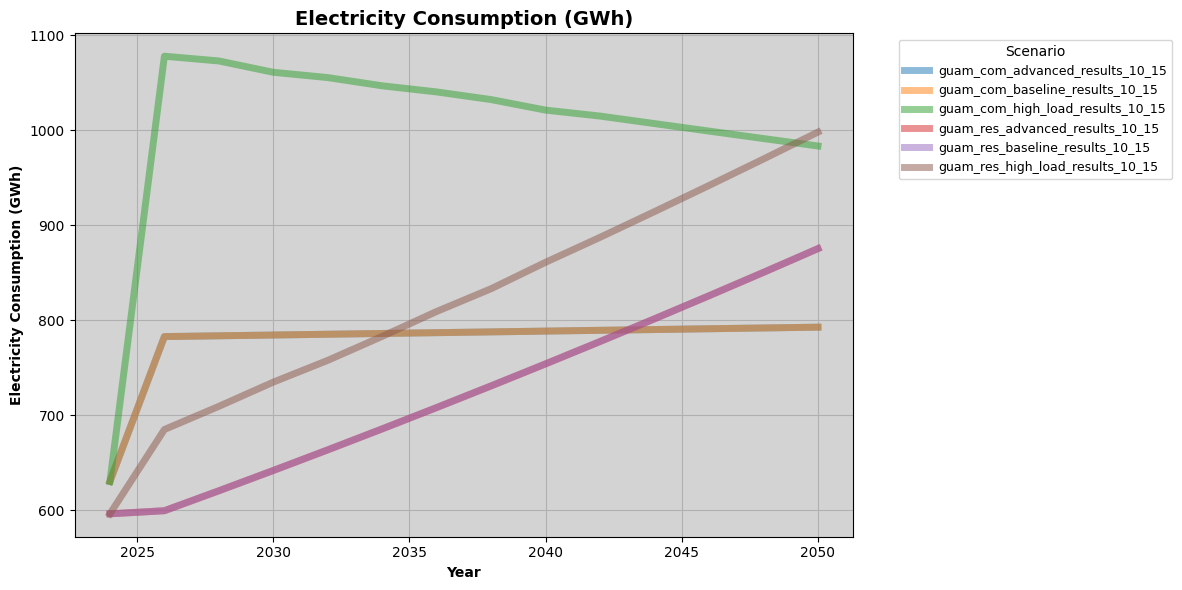

In [14]:
# =========================
# Chart 5: Electricity Consumption (GWh)
# =========================

# Calculate the load_kwh for each scenario
for df_name, df in scenario_dictionary.items():
    df['load_kwh'] = df['load_multiplier'] * df['load_kwh_per_customer_in_bin'] * df['customers_in_bin']
    print(f'--- {df_name} ---')  # label with the DataFrame name
    display(df.head())           # display the first few rows
    print('\n')

# Define a consistent color palette
colors_load = plt.cm.tab10.colors  

# Create a plot
fig_load, ax_load = plt.subplots(figsize=(12, 6))

# Loop through each DataFrame in the dictionary
for i, (name, df) in enumerate(scenario_dictionary.items()):
    # Aggregate load_kwh by year and convert kWh → GWh
    df_grouped_load = df.groupby('year', as_index=False)['load_kwh'].sum()
    df_grouped_load['load_gwh'] = df_grouped_load['load_kwh'] / 1000000
    
    # Plot line for this scenario
    ax_load.plot(df_grouped_load['year'], df_grouped_load['load_gwh'], 
                     label=name, color=colors_load[i % len(colors_load)], linewidth=5, alpha=0.5)

# Formatting
ax_load.set_facecolor('lightgray')
ax_load.grid(True)

ax_load.set_title('Electricity Consumption (GWh)', fontsize=14, fontweight='bold')
ax_load.set_xlabel('Year', fontsize=10, fontweight='bold')
ax_load.set_ylabel('Electricity Consumption (GWh)', fontsize=10, fontweight='bold')

# Move legend outside the plot
ax_load.legend(title='Scenario', fontsize=9, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 8. Plot Results: Percent of Electricity Consumption Met by Distributed Solar PV Generation by Scenario

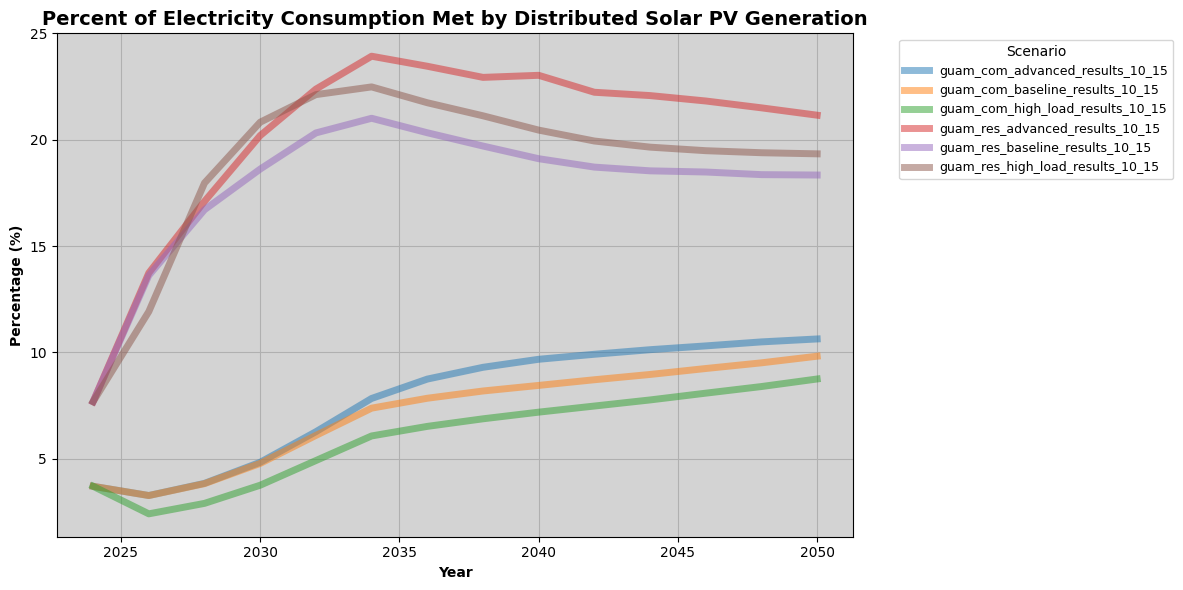

In [21]:
# =========================
# Chart 6: Percent of Electricity Consumption Met by Distributed Solar PV Generation
# =========================

# Calculate the load_kwh for each scenario (if not already calculated)
for df_name, df in scenario_dictionary.items():
    if 'load_kwh' not in df.columns:
        df['load_kwh'] = df['load_multiplier'] * df['load_kwh_per_customer_in_bin'] * df['customers_in_bin']

# Define a consistent color palette
colors_percentage = plt.cm.tab10.colors  

# Create a plot
fig_percentage, ax_percentage = plt.subplots(figsize=(12, 6))

# Loop through each DataFrame in the dictionary
for i, (name, df) in enumerate(scenario_dictionary.items()):
    # Aggregate system capacity and capacity factor by year for generation calculation
    df_grouped_generation = (
        df.groupby('year', as_index=False)
          .agg({
              'system_kw_cum': 'sum',
              'capacity_factor': 'mean'
          })
    )
    
    # Estimate generation (kWh) = capacity (kW) × capacity factor × 8760 hours
    df_grouped_generation['annual_energy_production_kwh'] = (
        df_grouped_generation['system_kw_cum'] * 
        df_grouped_generation['capacity_factor'] * 
        8760
    )
    
    # Aggregate load_kwh by year for consumption calculation
    df_grouped_load = df.groupby('year', as_index=False)['load_kwh'].sum()
    
    # Merge generation and load data on year
    df_merged = df_grouped_generation.merge(df_grouped_load, on='year')
    
    # Calculate percentage of consumption met by solar PV
    df_merged['pv_percentage'] = (df_merged['annual_energy_production_kwh'] / df_merged['load_kwh']) * 100
    
    # Plot line for this scenario
    ax_percentage.plot(df_merged['year'], df_merged['pv_percentage'], 
                      label=name, color=colors_percentage[i % len(colors_percentage)], linewidth=5, alpha=0.5)

# Formatting
ax_percentage.set_facecolor('lightgray')
ax_percentage.grid(True)

ax_percentage.set_title('Percent of Electricity Consumption Met by Distributed Solar PV Generation', fontsize=14, fontweight='bold')
ax_percentage.set_xlabel('Year', fontsize=10, fontweight='bold')
ax_percentage.set_ylabel('Percentage (%)', fontsize=10, fontweight='bold')

# Move legend outside the plot
ax_percentage.legend(title='Scenario', fontsize=9, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()